# Week 7 Lab — CatBoost + GridSearchCV + RandomizedSearchCV + Optuna on Titanic

## 실습 목표
1. **범주형 feature가 포함된 Titanic 데이터**로 CatBoost를 실습한다.
2. 복잡한 One-Hot Encoding 없이 **CatBoost baseline**을 만든다.
3. **GridSearchCV**와 **RandomizedSearchCV**를 간략히 적용해본다.
4. **Optuna**로 CatBoost 하이퍼파라미터를 간단히 최적화한다.
5. 모든 모델의 train / valid / test 성능을 Accuracy + AUC 기준으로 비교한다.

---

## 오늘 실습 데이터
- 데이터셋: `week04 hw02 file/titanic.csv`
- 이유:
  - 범주형 + 수치형이 섞여 있어 CatBoost 강점을 확인하기 좋음
  - 이미 수업 문맥 안에 있는 데이터라 모델 자체에 집중 가능
  - 40분 안에 baseline과 Optuna tuning을 모두 보기 적합함

> 오늘 핵심은 **"전처리를 많이 했다"** 가 아니라  
> **"CatBoost가 범주형 데이터를 더 간결하게 다루고, 탐색 전략에 따라 실험 효율이 달라진다"** 입니다.


> **🗣️ [발표자 스크립트]**  
> "이번 실습에서는 범주형 변수가 있는 Titanic 데이터로 CatBoost를 써보겠습니다.  
> One-Hot Encoding 파이프라인을 길게 만들지 않고도 baseline을 만들 수 있다는 점이 첫 번째 포인트고,  
> 그 위에 GridSearchCV, RandomizedSearchCV, Optuna를 순서대로 얹어서 탐색 전략의 차이까지 같이 보겠습니다."

## 실습 전 준비
- Python 3.10+
- Jupyter Notebook 또는 Colab
- `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`
- `catboost`, `optuna`


In [ ]:
# 필요 패키지 설치 (최초 1회만)
# 로컬 uv 환경 예시
# !uv add pandas numpy matplotlib seaborn scikit-learn catboost optuna

# Colab / 일반 Jupyter 환경 예시
# !pip install pandas numpy matplotlib seaborn scikit-learn catboost optuna


Resolved 269 packages in 796ms                                       
⠙ Preparing packages... (0/5)                                                   
⠙ Preparing packages... (0/5)-------------------     0 B/9.44 MiB            
⠙ Preparing packages... (0/5)-------------------     0 B/9.44 MiB            
narwhals             ------------------------------     0 B/436.51 KiB
⠙ Preparing packages... (0/5)-------------------     0 B/9.44 MiB            
narwhals             ------------------------------     0 B/436.51 KiB
⠙ Preparing packages... (0/5)------------------- 16.00 KiB/9.44 MiB          
narwhals             ------------------------------ 14.92 KiB/436.51 KiB
⠙ Preparing packages... (0/5)------------------- 16.00 KiB/9.44 MiB          
narwhals             ------------------------------ 14.92 KiB/436.51 KiB
⠙ Preparing packages... (0/5)------------------- 32.00 KiB/9.44 MiB          
narwhals             ------------------------------ 14.92 KiB/436.51 KiB
⠙ Preparing packages

## 1. 라이브러리 불러오기

In [25]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
from scipy.stats import randint, loguniform

try:
    from catboost import CatBoostClassifier, Pool
except ImportError as e:
    raise ImportError("catboost가 설치되어 있지 않습니다. 설치 셀을 먼저 확인하세요.") from e

try:
    import optuna
except ImportError as e:
    raise ImportError("optuna가 설치되어 있지 않습니다. 설치 셀을 먼저 확인하세요.") from e

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 2. Titanic 데이터 로드

In [26]:
data_path = Path.cwd() / "week04 hw02 file" / "titanic.csv"
if not data_path.exists():
    raise FileNotFoundError(f"Titanic CSV를 찾을 수 없습니다: {data_path}")

df = pd.read_csv(data_path)
display(df.head())
print("shape:", df.shape)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


shape: (891, 12)


## 3. 간단한 컬럼 선택과 데이터 준비

- CatBoost가 범주형을 직접 다룰 수 있어도,
- 명백한 ID성 컬럼이나 누수가 될 만한 컬럼은 정리하는 편이 좋습니다.


In [27]:
use_cols = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
target_col = "Survived"

work_df = df[use_cols + [target_col]].copy()

# CatBoost에서 범주형으로 처리할 컬럼은 문자열로 두면 해석이 명확합니다.
work_df["Pclass"] = work_df["Pclass"].astype(str)
work_df["Sex"] = work_df["Sex"].astype(str)
work_df["Embarked"] = work_df["Embarked"].fillna("Missing").astype(str)

display(work_df.head())
work_df.isna().sum().to_frame("missing_count")


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


,missing_count
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,0
Survived,0


## 4. Train / Validation / Test Split

In [28]:
X = work_df.drop(columns=target_col)
y = work_df[target_col]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=RANDOM_STATE
)

cat_features = ["Pclass", "Sex", "Embarked"]

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test :", X_test.shape)
print("cat_features:", cat_features)


X_train: (534, 7)
X_valid: (178, 7)
X_test : (179, 7)
cat_features: ['Pclass', 'Sex', 'Embarked']


## 5. 평가 함수 정의

In [29]:
def evaluate_binary_classifier(model, X_train, X_valid, X_test, y_train, y_valid, y_test, model_name):
    train_pred = model.predict(X_train)
    valid_pred = model.predict(X_valid)
    test_pred = model.predict(X_test)

    train_pred = np.array(train_pred).reshape(-1)
    valid_pred = np.array(valid_pred).reshape(-1)
    test_pred = np.array(test_pred).reshape(-1)

    train_prob = model.predict_proba(X_train)[:, 1]
    valid_prob = model.predict_proba(X_valid)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    return {
        "model": model_name,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "valid_accuracy": accuracy_score(y_valid, valid_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "train_auc": roc_auc_score(y_train, train_prob),
        "valid_auc": roc_auc_score(y_valid, valid_prob),
        "test_auc": roc_auc_score(y_test, test_prob),
        "test_f1": f1_score(y_test, test_pred),
    }


def format_search_cv_results(search, search_name, metric_name):
    results = pd.DataFrame(search.cv_results_).copy()
    params_df = results["params"].apply(pd.Series)

    score_cols = ["rank_test_score", "mean_test_score", "std_test_score"]
    if "mean_train_score" in results.columns:
        score_cols.extend(["mean_train_score", "std_train_score"])

    formatted = pd.concat([results[score_cols], params_df], axis=1)
    formatted = formatted.rename(columns={
        "mean_test_score": f"cv_valid_{metric_name}",
        "std_test_score": f"cv_valid_{metric_name}_std",
        "mean_train_score": f"cv_train_{metric_name}",
        "std_train_score": f"cv_train_{metric_name}_std",
    })

    formatted.insert(0, "search", search_name)
    formatted.insert(1, "is_best", formatted["rank_test_score"].eq(1))
    formatted = formatted.sort_values(
        ["rank_test_score", f"cv_valid_{metric_name}"], ascending=[True, False]
    ).reset_index(drop=True)
    return formatted


def format_optuna_results(study, metric_name):
    trial_df = study.trials_dataframe()
    param_cols = [col for col in trial_df.columns if col.startswith("params_")]
    keep_cols = ["number", "value", "state"] + param_cols
    formatted = trial_df[keep_cols].copy()
    formatted = formatted.rename(columns={
        "number": "trial_number",
        "value": f"valid_{metric_name}",
    })
    formatted["is_best"] = formatted["trial_number"].eq(study.best_trial.number)
    formatted = formatted[["trial_number", "is_best", f"valid_{metric_name}", "state"] + param_cols]
    formatted = formatted.sort_values(f"valid_{metric_name}", ascending=False).reset_index(drop=True)
    return formatted


## 6. CatBoost Baseline

- 복잡한 One-Hot Encoding 없이 baseline을 만듭니다.
- `cat_features`만 지정해주면 CatBoost가 범주형 처리를 내부적으로 수행합니다.


In [30]:
train_pool = Pool(X_train, y_train, cat_features=cat_features)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)

cat_model = CatBoostClassifier(
    iterations=400,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=0,
    allow_writing_files=False,
)

cat_model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

baseline_result = evaluate_binary_classifier(
    cat_model, X_train, X_valid, X_test, y_train, y_valid, y_test, "CatBoost baseline"
)
print("best_iteration:", cat_model.get_best_iteration())
pd.DataFrame([baseline_result])


best_iteration: 89


,model,train_accuracy,valid_accuracy,test_accuracy,train_auc,valid_auc,test_auc,test_f1
0,CatBoost baseline,0.85206,0.825843,0.798883,0.912077,0.890775,0.848551,0.704918


## 7. Baseline Feature Importance

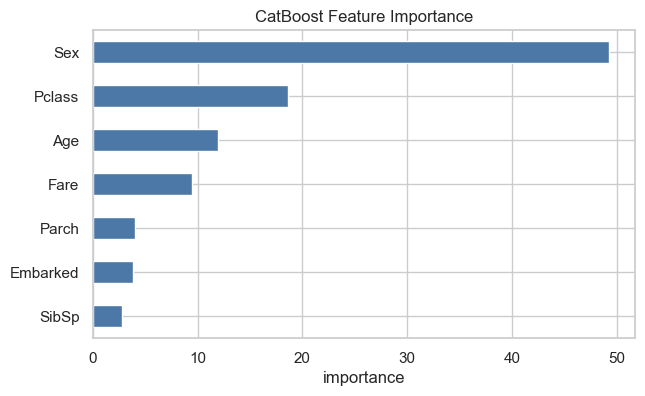

,importance
Sex,49.296549
Pclass,18.622080
Age,11.944027
Fare,9.429875
Parch,4.061890
Embarked,3.863272
SibSp,2.782306


In [31]:
feature_importance = pd.Series(cat_model.get_feature_importance(train_pool), index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(7, 4))
feature_importance.sort_values().plot(kind="barh", color="#4C78A8")
plt.title("CatBoost Feature Importance")
plt.xlabel("importance")
plt.show()

feature_importance.to_frame("importance")


## 8. GridSearchCV로 아주 작은 grid 탐색

- 먼저 **아주 작은 grid**만 써서 `GridSearchCV`를 가볍게 실행합니다.
- 목적은 exhaustive search의 감각을 보는 것이지, 큰 비용의 탐색을 하려는 것이 아닙니다.


In [32]:
cat_grid_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=0,
    allow_writing_files=False,
)

param_grid = {
    "iterations": [200, 400],
    "depth": [4, 6],
    "learning_rate": [0.03, 0.05],
}

grid_search = GridSearchCV(
    estimator=cat_grid_model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    return_train_score=True,
    n_jobs=1,
    verbose=0,
)

grid_search.fit(X_train_full, y_train_full, cat_features=cat_features)

grid_history = format_search_cv_results(grid_search, "GridSearchCV", metric_name="auc")

grid_search_best = grid_search.best_estimator_
grid_search_result = evaluate_binary_classifier(
    grid_search_best,
    X_train,
    X_valid,
    X_test,
    y_train,
    y_valid,
    y_test,
    "CatBoost + GridSearchCV",
)

print("best_cv_valid_auc:", grid_search.best_score_)
print("best_params_:")
display(grid_search.best_params_)
display(grid_history.style.format({
    "cv_train_auc": "{:.4f}",
    "cv_valid_auc": "{:.4f}",
    "cv_train_auc_std": "{:.4f}",
    "cv_valid_auc_std": "{:.4f}",
    "learning_rate": "{:.4f}",
}))
pd.DataFrame([grid_search_result])


best_cv_valid_auc: 0.8690459123084228
best_params_:


{'depth': 4, 'iterations': 400, 'learning_rate': 0.05}

,search,is_best,rank_test_score,cv_valid_auc,cv_valid_auc_std,cv_train_auc,cv_train_auc_std,depth,iterations,learning_rate
0,GridSearchCV,True,1,0.8690,0.0062,0.9551,0.0088,4.000000,400.000000,0.0500
1,GridSearchCV,False,2,0.8685,0.0103,0.9270,0.0053,6.000000,200.000000,0.0300
2,GridSearchCV,False,3,0.8675,0.0171,0.9532,0.0083,6.000000,400.000000,0.0300
3,GridSearchCV,False,4,0.8653,0.0103,0.9475,0.0065,6.000000,200.000000,0.0500
4,GridSearchCV,False,5,0.8651,0.0068,0.9398,0.0058,4.000000,400.000000,0.0300
5,GridSearchCV,False,6,0.8627,0.0138,0.9689,0.0095,6.000000,400.000000,0.0500
6,GridSearchCV,False,7,0.8622,0.0025,0.9309,0.0044,4.000000,200.000000,0.0500
7,GridSearchCV,False,8,0.8621,0.0051,0.9091,0.0031,4.000000,200.000000,0.0300


,model,train_accuracy,valid_accuracy,test_accuracy,train_auc,valid_auc,test_auc,test_f1
0,CatBoost + GridSearchCV,0.88015,0.91573,0.826816,0.936741,0.959291,0.853953,0.752


## 9. RandomizedSearchCV로 가벼운 baseline tuning

- 먼저 `RandomizedSearchCV`로 비교적 가벼운 tuning을 해봅니다.
- 목적은 **Scikit-learn 스타일의 랜덤 탐색 + CV** 흐름을 체감하는 것입니다.


In [33]:
cat_search_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=0,
    allow_writing_files=False,
)

param_distributions = {
    "iterations": randint(200, 601),
    "depth": randint(4, 9),
    "learning_rate": loguniform(0.01, 0.2),
    "l2_leaf_reg": loguniform(1.0, 10.0),
}

random_search = RandomizedSearchCV(
    estimator=cat_search_model,
    param_distributions=param_distributions,
    n_iter=8,
    scoring="roc_auc",
    cv=3,
    return_train_score=True,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=0,
)

random_search.fit(X_train_full, y_train_full, cat_features=cat_features)

random_search_history = format_search_cv_results(random_search, "RandomizedSearchCV", metric_name="auc")

random_search_best = random_search.best_estimator_
random_search_result = evaluate_binary_classifier(
    random_search_best,
    X_train,
    X_valid,
    X_test,
    y_train,
    y_valid,
    y_test,
    "CatBoost + RandomizedSearchCV",
)

print("best_cv_valid_auc:", random_search.best_score_)
print("best_params_:")
display(random_search.best_params_)
display(random_search_history.style.format({
    "cv_train_auc": "{:.4f}",
    "cv_valid_auc": "{:.4f}",
    "cv_train_auc_std": "{:.4f}",
    "cv_valid_auc_std": "{:.4f}",
    "learning_rate": "{:.4f}",
    "l2_leaf_reg": "{:.4f}",
}))
pd.DataFrame([random_search_result])


best_cv_valid_auc: 0.8673471947863897
best_params_:


{'depth': 5,
 'iterations': 391,
 'l2_leaf_reg': np.float64(9.822263016087534),
 'learning_rate': np.float64(0.06358606736176979)}

,search,is_best,rank_test_score,cv_valid_auc,cv_valid_auc_std,cv_train_auc,cv_train_auc_std,depth,iterations,l2_leaf_reg,learning_rate
0,RandomizedSearchCV,True,1,0.8673,0.0116,0.9572,0.0087,5.000000,391.000000,9.8223,0.0636
1,RandomizedSearchCV,False,2,0.8666,0.0074,0.9279,0.0065,8.000000,302.000000,2.7915,0.0135
2,RandomizedSearchCV,False,3,0.8640,0.0076,0.9203,0.0038,6.000000,287.000000,2.1563,0.0153
3,RandomizedSearchCV,False,4,0.8630,0.0196,0.9757,0.0116,6.000000,349.000000,1.1387,0.0870
4,RandomizedSearchCV,False,5,0.8611,0.0079,0.9101,0.0039,6.000000,258.000000,2.5111,0.0115
5,RandomizedSearchCV,False,6,0.8607,0.0056,0.9056,0.0042,5.000000,221.000000,1.0164,0.0107
6,RandomizedSearchCV,False,7,0.8593,0.0181,0.9788,0.0068,7.000000,470.000000,2.8581,0.1051
7,RandomizedSearchCV,False,8,0.8591,0.0180,0.9797,0.0063,7.000000,548.000000,1.5256,0.1034


,model,train_accuracy,valid_accuracy,test_accuracy,train_auc,valid_auc,test_auc,test_f1
0,CatBoost + RandomizedSearchCV,0.872659,0.932584,0.815642,0.938943,0.960628,0.860079,0.736


## 10. Optuna로 하이퍼파라미터 최적화

- 실습 시간 안에서는 trial 수를 작게 둡니다.
- 목적은 최고의 점수보다 **탐색 흐름**을 이해하는 것입니다.


In [34]:
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "random_strength": trial.suggest_float("random_strength", 0.0, 5.0),
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "random_seed": RANDOM_STATE,
        "verbose": 0,
        "allow_writing_files": False,
    }

    model = CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

    valid_prob = model.predict_proba(X_valid)[:, 1]
    valid_auc = roc_auc_score(y_valid, valid_prob)
    return valid_auc


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15, show_progress_bar=False)

optuna_history = format_optuna_results(study, metric_name="auc")

print("best_valid_auc:", study.best_value)
print("best_params:")
display(study.best_params)
display(optuna_history.style.format({
    "valid_auc": "{:.4f}",
    "params_learning_rate": "{:.4f}",
    "params_l2_leaf_reg": "{:.4f}",
    "params_random_strength": "{:.4f}",
}))


[I 2026-04-12 23:37:50,323] A new study created in memory with name: no-name-60ffcc87-4ee7-419d-a310-95a4497b5dc8
[I 2026-04-12 23:37:50,888] Trial 0 finished with value: 0.8782754010695186 and parameters: {'iterations': 457, 'learning_rate': 0.011922964463013067, 'depth': 10, 'l2_leaf_reg': 1.4240295527108535, 'random_strength': 1.3887810802240579}. Best is trial 0 with value: 0.8782754010695186.
[I 2026-04-12 23:37:51,199] Trial 1 finished with value: 0.877139037433155 and parameters: {'iterations': 208, 'learning_rate': 0.013662719717343348, 'depth': 9, 'l2_leaf_reg': 9.212067146758507, 'random_strength': 1.035004402700913}. Best is trial 0 with value: 0.8782754010695186.
[I 2026-04-12 23:37:51,595] Trial 2 finished with value: 0.8735294117647059 and parameters: {'iterations': 414, 'learning_rate': 0.01655934323419246, 'depth': 7, 'l2_leaf_reg': 9.13603893765006, 'random_strength': 2.311683535769125}. Best is trial 0 with value: 0.8782754010695186.
[I 2026-04-12 23:37:52,032] Trial 

best_valid_auc: 0.891644385026738
best_params:


{'iterations': 509,
 'learning_rate': 0.12571033141583143,
 'depth': 10,
 'l2_leaf_reg': 3.370791055060456,
 'random_strength': 4.087099492708161}

,trial_number,is_best,valid_auc,state,params_depth,params_iterations,params_l2_leaf_reg,params_learning_rate,params_random_strength
0,6,True,0.8916,COMPLETE,10,509,3.3708,0.1257,4.0871
1,5,False,0.8890,COMPLETE,4,366,5.2467,0.0452,0.4739
2,11,False,0.8888,COMPLETE,4,526,3.1353,0.0615,0.1833
3,10,False,0.8867,COMPLETE,6,595,1.0629,0.1867,4.7787
4,13,False,0.8854,COMPLETE,6,325,3.4537,0.1115,0.4478
5,12,False,0.8846,COMPLETE,4,503,7.4420,0.1505,3.8502
6,4,False,0.8845,COMPLETE,8,260,5.4494,0.0270,3.3897
7,14,False,0.8843,COMPLETE,8,555,2.8008,0.0452,2.9384
8,8,False,0.8789,COMPLETE,9,398,3.9730,0.0859,3.2638
9,7,False,0.8785,COMPLETE,7,219,5.2745,0.0207,1.9941


## 11. Best Trial로 모델 재학습

In [35]:
best_params = study.best_params.copy()
best_params.update({
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "random_seed": RANDOM_STATE,
    "verbose": 0,
    "allow_writing_files": False,
})

cat_tuned = CatBoostClassifier(**best_params)
cat_tuned.fit(train_pool, eval_set=valid_pool, use_best_model=True)

tuned_result = evaluate_binary_classifier(
    cat_tuned, X_train, X_valid, X_test, y_train, y_valid, y_test, "CatBoost + Optuna"
)
print("best_iteration:", cat_tuned.get_best_iteration())
pd.DataFrame([tuned_result])


best_iteration: 38


,model,train_accuracy,valid_accuracy,test_accuracy,train_auc,valid_auc,test_auc,test_f1
0,CatBoost + Optuna,0.833333,0.831461,0.810056,0.89163,0.891644,0.850659,0.716667


In [36]:
comparison_df = pd.DataFrame([
    baseline_result,
    grid_search_result,
    random_search_result,
    tuned_result,
])
comparison_df.style.format({
    "train_accuracy": "{:.3f}",
    "valid_accuracy": "{:.3f}",
    "test_accuracy": "{:.3f}",
    "train_auc": "{:.3f}",
    "valid_auc": "{:.3f}",
    "test_auc": "{:.3f}",
    "test_f1": "{:.3f}",
})


,model,train_accuracy,valid_accuracy,test_accuracy,train_auc,valid_auc,test_auc,test_f1
0,CatBoost baseline,0.852,0.826,0.799,0.912,0.891,0.849,0.705
1,CatBoost + GridSearchCV,0.880,0.916,0.827,0.937,0.959,0.854,0.752
2,CatBoost + RandomizedSearchCV,0.873,0.933,0.816,0.939,0.961,0.860,0.736
3,CatBoost + Optuna,0.833,0.831,0.810,0.892,0.892,0.851,0.717


## 12. Train / Valid / Test 성능 비교 그래프

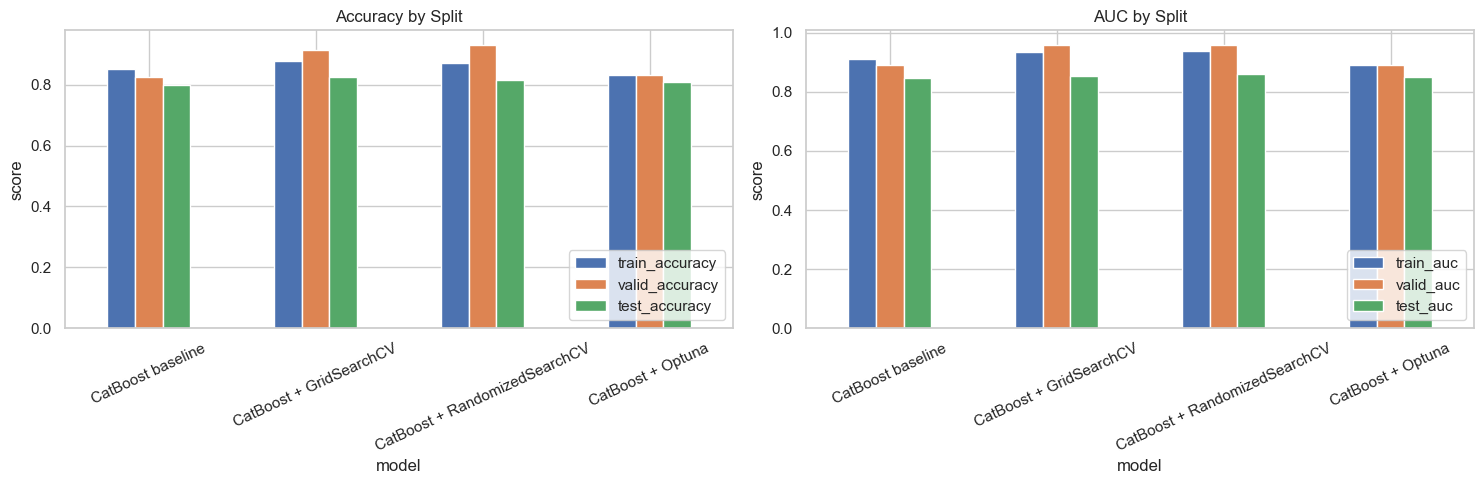

In [37]:
plot_df = comparison_df.set_index("model")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_df[["train_accuracy", "valid_accuracy", "test_accuracy"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Accuracy by Split")
axes[0].set_ylabel("score")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(loc="lower right")

plot_df[["train_auc", "valid_auc", "test_auc"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("AUC by Split")
axes[1].set_ylabel("score")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


## 13. Confusion Matrix / Classification Report

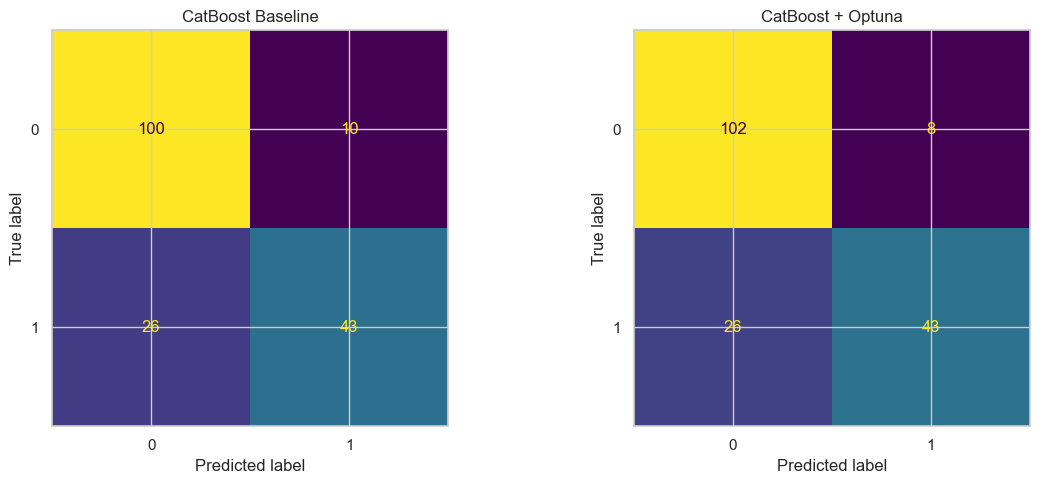

[CatBoost Baseline]
              precision    recall  f1-score   support

           0       0.79      0.91      0.85       110
           1       0.81      0.62      0.70        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179

[CatBoost + Optuna]
              precision    recall  f1-score   support

           0       0.80      0.93      0.86       110
           1       0.84      0.62      0.72        69

    accuracy                           0.81       179
   macro avg       0.82      0.78      0.79       179
weighted avg       0.81      0.81      0.80       179



In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, np.array(cat_model.predict(X_test)).reshape(-1), ax=axes[0], colorbar=False)
axes[0].set_title("CatBoost Baseline")

ConfusionMatrixDisplay.from_predictions(y_test, np.array(cat_tuned.predict(X_test)).reshape(-1), ax=axes[1], colorbar=False)
axes[1].set_title("CatBoost + Optuna")

plt.tight_layout()
plt.show()

print("[CatBoost Baseline]")
print(classification_report(y_test, np.array(cat_model.predict(X_test)).reshape(-1)))

print("[CatBoost + Optuna]")
print(classification_report(y_test, np.array(cat_tuned.predict(X_test)).reshape(-1)))


## 14. GridSearchCV / RandomizedSearchCV / Optuna 간단 비교

In [39]:
summary_compare = pd.DataFrame([
    baseline_result,
    grid_search_result,
    random_search_result,
    tuned_result,
])
summary_compare.style.format({
    "train_accuracy": "{:.3f}",
    "valid_accuracy": "{:.3f}",
    "test_accuracy": "{:.3f}",
    "train_auc": "{:.3f}",
    "valid_auc": "{:.3f}",
    "test_auc": "{:.3f}",
    "test_f1": "{:.3f}",
})


,model,train_accuracy,valid_accuracy,test_accuracy,train_auc,valid_auc,test_auc,test_f1
0,CatBoost baseline,0.852,0.826,0.799,0.912,0.891,0.849,0.705
1,CatBoost + GridSearchCV,0.880,0.916,0.827,0.937,0.959,0.854,0.752
2,CatBoost + RandomizedSearchCV,0.873,0.933,0.816,0.939,0.961,0.860,0.736
3,CatBoost + Optuna,0.833,0.831,0.810,0.892,0.892,0.851,0.717


## 15. Optuna Trial 결과 간단 확인

,trial_number,is_best,valid_auc,state,params_depth,params_iterations,params_l2_leaf_reg,params_learning_rate,params_random_strength
0,6,True,0.891644,COMPLETE,10,509,3.370791,0.125710,4.087099
1,5,False,0.889037,COMPLETE,4,366,5.246737,0.045235,0.473858
2,11,False,0.888770,COMPLETE,4,526,3.135311,0.061518,0.183348
3,10,False,0.886698,COMPLETE,6,595,1.062867,0.186723,4.778743
4,13,False,0.885428,COMPLETE,6,325,3.453704,0.111498,0.447792
5,12,False,0.884559,COMPLETE,4,503,7.442003,0.150490,3.850223
6,4,False,0.884492,COMPLETE,8,260,5.449447,0.026978,3.389699
7,14,False,0.884291,COMPLETE,8,555,2.800808,0.045152,2.938437
8,8,False,0.878877,COMPLETE,9,398,3.973037,0.085915,3.263833
9,7,False,0.878543,COMPLETE,7,219,5.274519,0.020683,1.994058


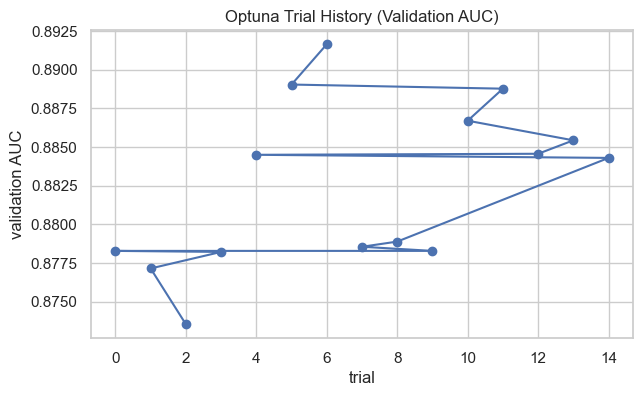

In [40]:
trials_df = optuna_history.copy()
display(trials_df)

plt.figure(figsize=(7, 4))
plt.plot(trials_df["trial_number"], trials_df["valid_auc"], marker="o")
plt.title("Optuna Trial History (Validation AUC)")
plt.xlabel("trial")
plt.ylabel("validation AUC")
plt.show()


## 16. 왜 `best_cv_valid_auc`와 최종 `test_auc`가 다를까?

- `GridSearchCV`와 `RandomizedSearchCV`의 `best_cv_valid_auc`는 **학습 데이터 내부에서 수행한 cross-validation 평균 점수**입니다.
- 반면 마지막 `summary_compare`의 `valid_auc`, `test_auc`는 **선정된 best hyperparameter로 모델을 다시 학습한 뒤, 별도로 나눈 validation / test split에서 측정한 점수**입니다.
- 즉, 두 값은 같은 모델 계열을 보지만 **평가 데이터와 평가 절차가 다르기 때문에 숫자가 같을 필요가 없습니다.**
- Optuna도 동일합니다. `best_valid_auc`는 trial 탐색 기준 점수이고, 마지막 표는 best trial 파라미터로 재학습한 뒤의 hold-out 성능입니다.
- 수업에서는 이 차이를 통해 **튜닝 점수와 실제 일반화 성능은 구분해서 봐야 한다**는 점을 강조하면 좋습니다.


## 17. 실습 해석 가이드

### 확인할 포인트
1. One-Hot Encoding 없이도 CatBoost baseline이 충분히 강했는가?
2. 어떤 파라미터가 성능 변화에 가장 민감하게 반응했는가?
3. GridSearchCV, RandomizedSearchCV, Optuna 중 어떤 방식이 가장 실용적으로 느껴졌는가?
4. `RandomizedSearchCV`와 Optuna 중 어떤 방식이 더 실험 효율적으로 느껴졌는가?
5. Optuna가 trial을 쌓아가며 더 나은 영역을 찾는 흐름이 보였는가?
6. tuned model이 validation / test 기준 모두 개선되었는가?
7. 이 과정을 큰 Grid Search로 했다면 얼마나 더 비쌌을까?

### 한 줄 정리
- **CatBoost는 전처리 비용을 줄이고, Optuna는 탐색 비용을 줄인다.**


## 18. 중간고사 전 연결 포인트

- CatBoost가 해결하는 문제: 범주형 전처리 부담
- RandomizedSearchCV가 제공하는 것: 가벼운 baseline tuning
- Optuna가 해결하는 문제: 더 똑똑한 탐색 효율성
- NGBoost가 확장하는 관점: 예측값뿐 아니라 불확실성까지 보기

즉, 7주차는 **모델 성능 + 전처리 효율 + 탐색 효율 + uncertainty 관점**을 한 번에 정리하는 주차입니다.
